# Bank Marketing Campaign Prediction

### Objective

Develop a machine learning model to predict whether a customer will subscribe to a term deposit. The predicted probabilities are then used to rank customers and optimize marketing campaign costs using Gains and Lift Analysis.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

[Dataset link](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset)

In [2]:
# reading the dataset
data = pd.read_csv("bank.csv")

In [3]:
# displaying the dataset
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Columns and Description

| **Column** | **Description** |
|------------|-----------------|
| **age** | Age of the customer. |
| **job** | Type of occupation |
| **marital** | Marital status of the customer. |
| **education** | Highest level of education attained. |
| **default** | Indicates whether the customer has credit in default. |
| **balance** | Average yearly balance in the customer's bank account. |
| **housing** | Indicates whether the customer has a housing loan. |
| **loan** | Indicates whether the customer has a personal loan. |
| **contact** | Communication method used to contact the customer. |
| **day** | Day of the month when the customer was last contacted. |
| **month** | Month in which the customer was last contacted. |
| **duration** | Duration of the last contact call. |
| **campaign** | Number of contacts made with the customer during the current marketing campaign. |
| **pdays** | Number of days since the customer was last contacted in a previous campaign. A value of `-1` indicates the customer was not previously contacted. |
| **previous** | Number of contacts made with the customer before the current campaign. |
| **poutcome** | Outcome of the previous marketing campaign. |
| **deposit** | **Target variable** indicating whether the customer subscribed to a term deposit. |

In [21]:
# displaying the data types in each column of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
# checking for null values in the dataset
data.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [15]:
# checking the proportion of unknown values
data["contact"].value_counts(normalize=True)* 100

,proportion
contact,
cellular,72.048020
unknown,21.017739
telephone,6.934241


In [16]:
# checking the proportion of unknown values
data["poutcome"].value_counts(normalize=True) * 100

,proportion
poutcome,
unknown,74.592367
failure,11.001613
success,9.595055
other,4.810966


In [20]:
# checking the target class proportion
data["deposit"].value_counts(normalize=True) * 100

,proportion
deposit,
no,52.616019
yes,47.383981


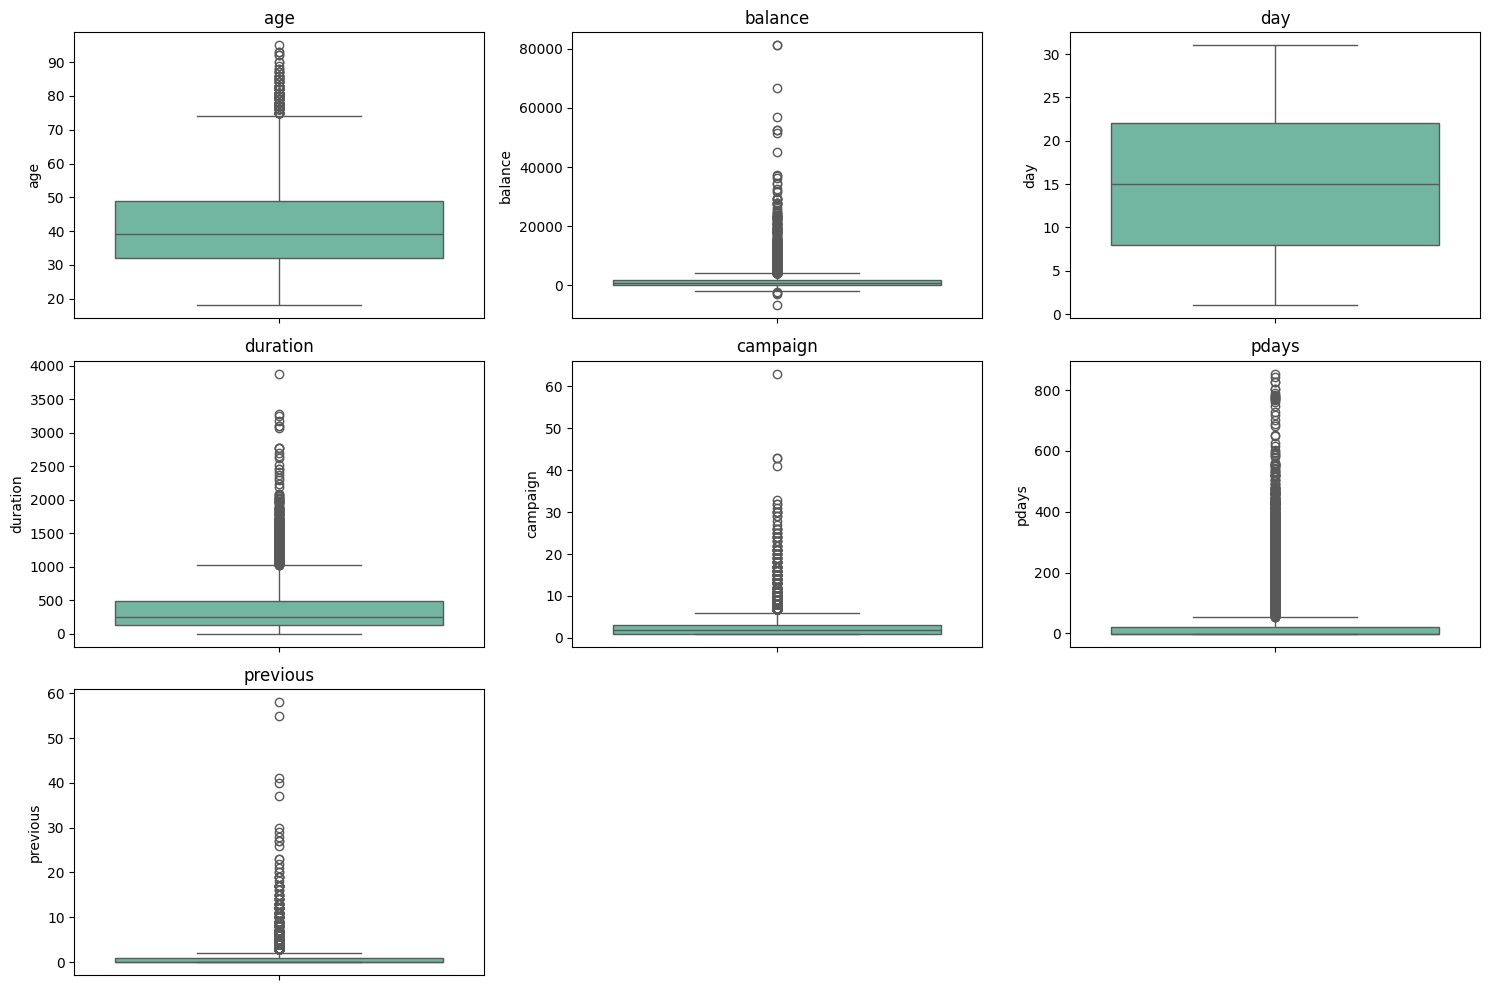

In [37]:
# Visualizing numerical features using boxplots to identify potential outliers
plt.figure(figsize=(15,10))

for i, col in enumerate(data.select_dtypes(include= "int")):
  plt.subplot(3,3, i+1)
  sns.boxplot(data[col], palette= "Set2")
  plt.title(col)

plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

The identified outliers were retained because they represent genuine customer behavior rather than data entry errors. Removing these observations could eliminate valuable information regarding customer financial characteristics and campaign interactions. Since tree-based machine learning models are robust to outliers, no outlier treatment was performed.

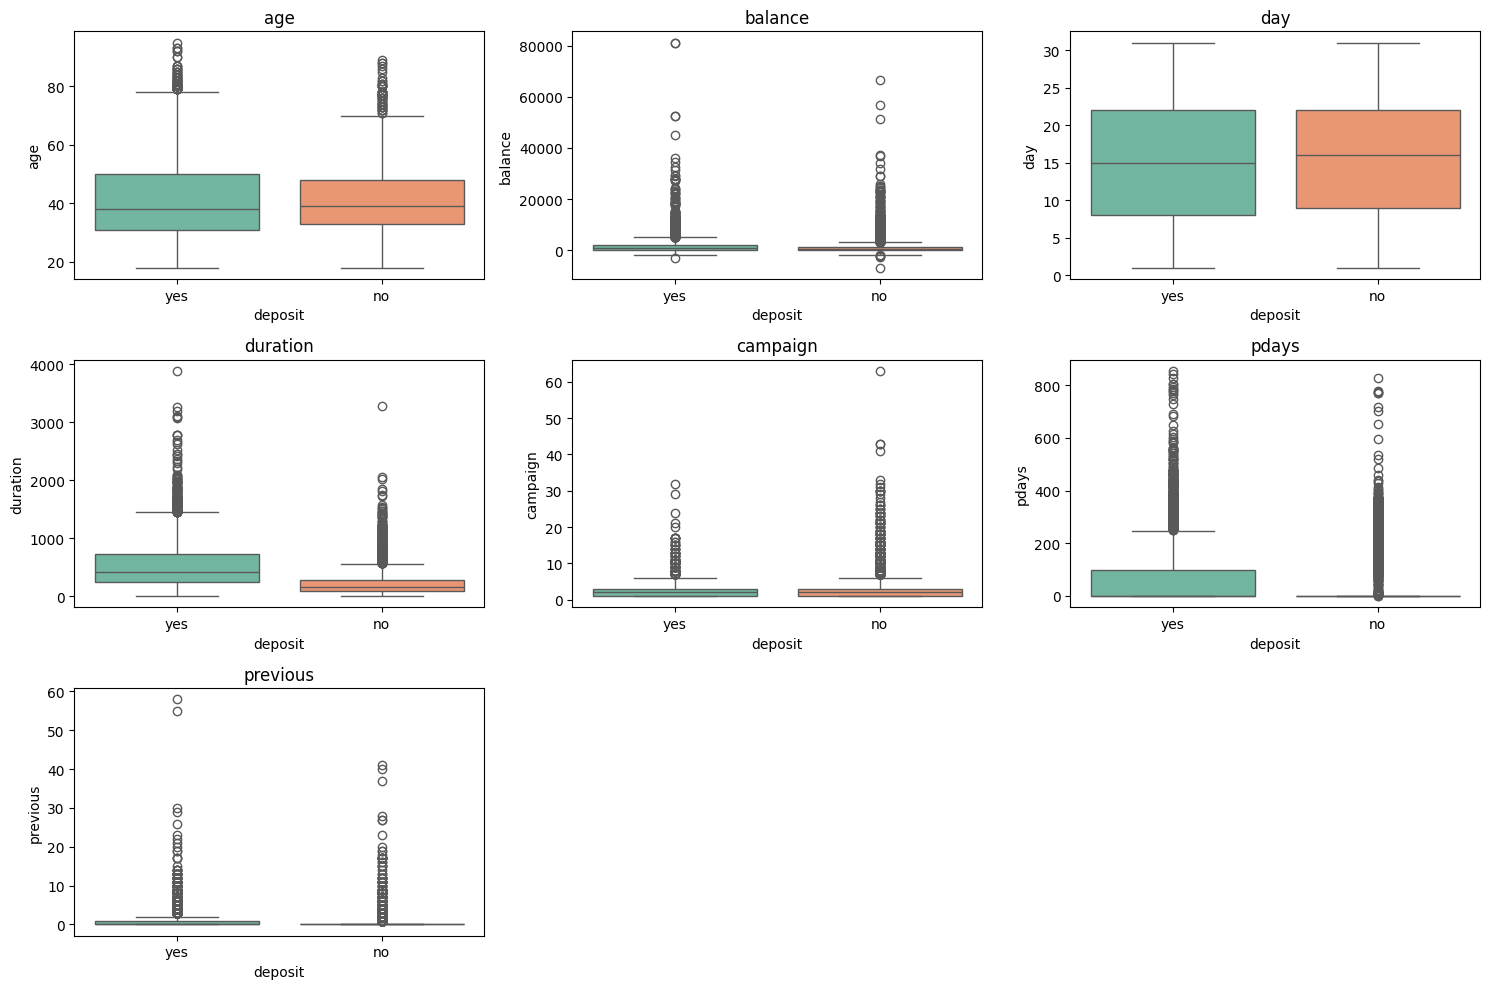

In [33]:
# Visualizing numerical features by deposit class
plt.figure(figsize=(15,10))

for i, col in enumerate(data.select_dtypes(include= "int")):
  plt.subplot(3,3, i+1)
  sns.boxplot(x= "deposit", y = col, data = data, palette= "Set2")
  plt.title(col)

plt.tight_layout()
plt.show()




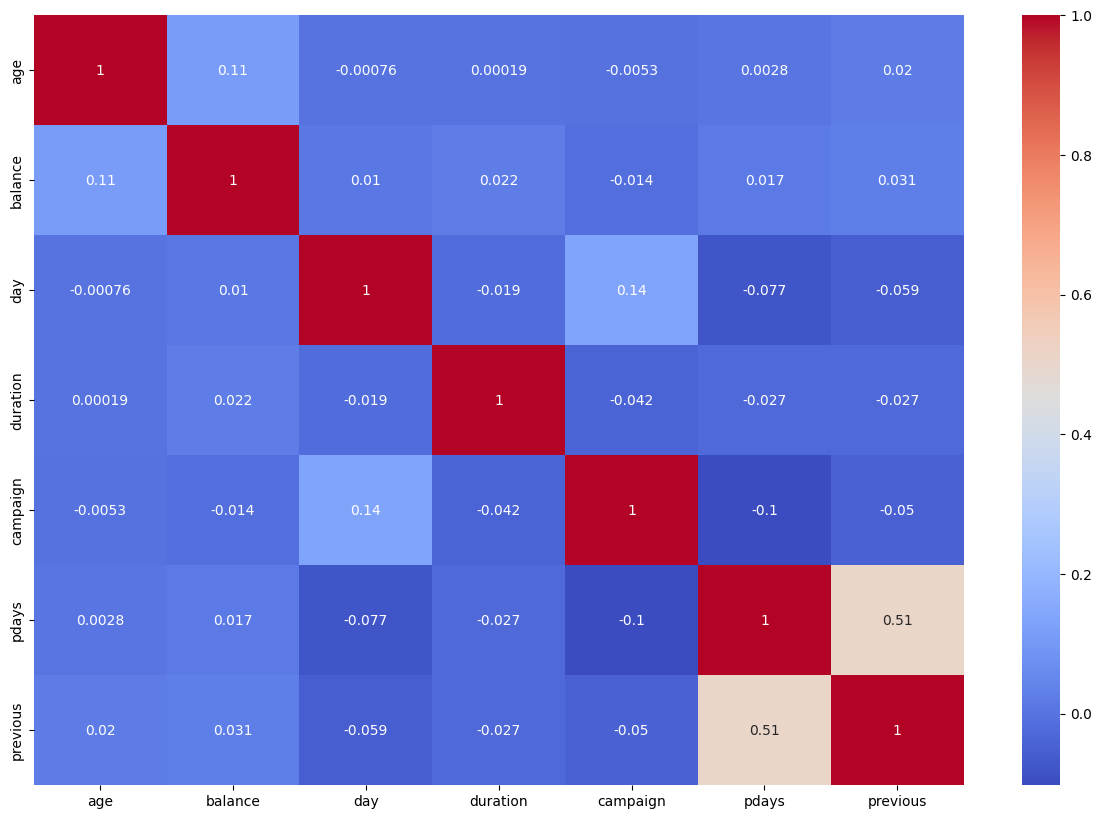

In [38]:
# Correlation analysis among numerical features
corr = data.select_dtypes(include= "int").corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot= True, cmap= "coolwarm")
plt.show()

In [44]:
# Comparing average numerical feature values across deposit classes

data.groupby("deposit")[["age","balance","day","duration"]].mean().T

deposit,no,yes
age,40.837391,41.670070
balance,1280.227141,1804.267915
day,16.108122,15.158253
duration,223.130257,537.294574


In [45]:
# selecting the categorical columns
data.select_dtypes(include= "object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

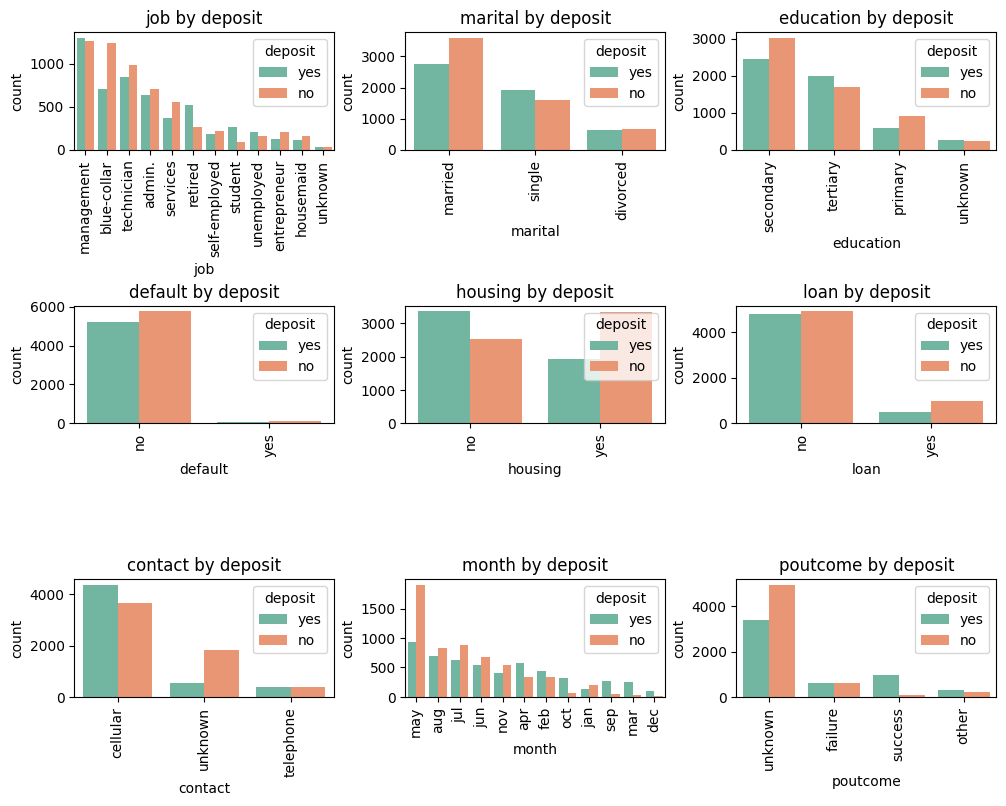

In [47]:
# plotting the categorical columns by deposit
plt.figure(figsize=(10,8))
for i, col in enumerate(data.select_dtypes(include="object").columns):
  if col != "deposit":
    plt.subplot(3,3,i+1)
    sns.countplot(data = data, x= col, palette= "Set2",
                  hue= "deposit",
                  order = data[col].value_counts().index)
    plt.title(f"{col} by deposit")
    plt.xticks(rotation = 90)

plt.tight_layout(pad = 0.5)
plt.show()

In [50]:
# Encoding categorical features using Label Encoding
encoder_dic = {}
for col in data.select_dtypes(include="object"):
  encoder = LabelEncoder()
  data[col] = encoder.fit_transform(data[col])
  encoder_dic[col] = encoder

In [51]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [52]:
# Display the category-to-label mapping for each categorical feature
for i in encoder_dic:
  print(f"{i} : {encoder_dic[i].classes_}")

job : ['admin.' 'blue-collar' 'entrepreneur' 'housemaid' 'management' 'retired'
 'self-employed' 'services' 'student' 'technician' 'unemployed' 'unknown']
marital : ['divorced' 'married' 'single']
education : ['primary' 'secondary' 'tertiary' 'unknown']
default : ['no' 'yes']
housing : ['no' 'yes']
loan : ['no' 'yes']
contact : ['cellular' 'telephone' 'unknown']
month : ['apr' 'aug' 'dec' 'feb' 'jan' 'jul' 'jun' 'mar' 'may' 'nov' 'oct' 'sep']
poutcome : ['failure' 'other' 'success' 'unknown']
deposit : ['no' 'yes']


In [53]:
# separate the predictor features (x) and target variable (y)
x = data.drop("deposit", axis= 1)
y = data["deposit"]
x.shape, y.shape

((11162, 16), (11162,))

In [54]:
# split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [55]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8929, 16), (2233, 16), (8929,), (2233,))

In [58]:
# initialize tree based classification models with hyperparameters

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42,
                                            class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=False
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        class_weight="balanced"
    )
}

grid_param = {

    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    "Extra Trees": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
        "gamma": [0, 0.1, 0.3]
    },

    "CatBoost": {
        "iterations": [100, 200],
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.1],
        "l2_leaf_reg": [3, 5, 7]
    },

    "LightGBM": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [-1, 5, 10],
        "num_leaves": [31, 50, 70]
    }
}

In [63]:
# Train and optimize each model using RandomizedSearchCV
best_model ={}
results =[]
for model_name, model in models.items():
  grid_search = RandomizedSearchCV(
      model,
      param_distributions= grid_param[model_name],
      n_iter=10,
      cv=3,
      n_jobs=-1,
      verbose=False,
      random_state=42
  )
  grid_search.fit(x_train, y_train)
  best_model[model_name] = grid_search.best_estimator_
  y_pred = best_model[model_name].predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  results.append({
      "Model": model_name,
      "Best Parameters": grid_search.best_params_,
      "Accuracy": accuracy
  })

results_df = pd.DataFrame(results, columns=["Model", "Best Parameters", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False, inplace=True)
results_df

[LightGBM] [Info] Number of positive: 4222, number of negative: 4707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 964
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Model,Best Parameters,Accuracy
3,XGBoost,"{'subsample': 0.8, 'n_estimators': 200, 'max_d...",0.846395
4,CatBoost,"{'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iter...",0.843708
5,LightGBM,"{'num_leaves': 70, 'n_estimators': 100, 'max_d...",0.839230
1,Random Forest,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.832064
2,Extra Trees,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.819525
0,Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.797134


In [64]:
# Predict the target labels on the test dataset using the best-performing model
final_model = best_model["XGBoost"]
y_pred = final_model.predict(x_test)

In [65]:
# Evaluate the model using the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1166
           1       0.82      0.87      0.84      1067

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



The optimized classification model achieved an overall accuracy of 85% on the test dataset. For the positive class (customers subscribing to a term deposit), the model achieved a precision of 82%, indicating that most customers predicted as subscribers actually subscribed. The recall of 87% demonstrates the model's ability to identify the majority of potential subscribers, which is particularly important for marketing campaigns. The F1-score of 84% reflects a good balance between precision and recall. Overall, the model exhibits balanced performance across both classes, making it suitable for customer targeting and campaign optimization.

In [66]:
# Predict the probability of subscription for each customer
y_pred_prob = final_model.predict_proba(x)
y_pred_prob

array([[0.12261957, 0.87738043],
       [0.11667603, 0.88332397],
       [0.16432244, 0.83567756],
       ...,
       [0.94093466, 0.05906536],
       [0.9979276 , 0.00207238],
       [0.24223548, 0.7577645 ]], dtype=float32)

In [67]:
# store the predicted probability of customer subscribing to the term deposit
data["prob_yes"] = y_pred_prob[:,1]
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,prob_yes
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1,0.877380
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1,0.883324
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1,0.835678
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1,0.260066
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1,0.581923


In [68]:
# Rank customers into deciles based on their predicted probability of subscription
data["rank"] = 10- pd.qcut(data["prob_yes"], 10, labels= False)
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,prob_yes,rank
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1,0.877380,3
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1,0.883324,3
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1,0.835678,4
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1,0.260066,6
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1,0.581923,5


In [71]:
# Construct the Gains and Lift table for campaign evaluation
gain = data.groupby("rank").agg(
    subscribers = ("deposit", "sum"),
    total_customers = ("deposit", "count")
)

gain.sort_values(by="rank", ascending= True, inplace= True)
gain["conversion_rate_%"] = gain["subscribers"] / gain["total_customers"]
gain["cumulative_subscribers"] = gain["subscribers"].cumsum()
gain["cumulative_gains_%"] = gain["cumulative_subscribers"] / gain["subscribers"].sum()
gain["lift"] = gain["cumulative_gains_%"] / (
    gain["total_customers"].cumsum() / gain["total_customers"].sum())
gain = gain.reset_index()
gain.to_csv("gain_table.csv", index= False)
gain

,rank,subscribers,total_customers,conversion_rate_%,cumulative_subscribers,cumulative_gains_%,lift
0,1,1104,1117,0.988362,1104,0.208735,2.085856
1,2,1085,1116,0.972222,2189,0.413878,2.068833
2,3,1058,1116,0.948029,3247,0.613916,2.046141
3,4,952,1116,0.853047,4199,0.793912,1.984691
4,5,689,1116,0.617384,4888,0.924182,1.848365
5,6,325,1116,0.291219,5213,0.985631,1.642767
6,7,58,1116,0.051971,5271,0.996597,1.423782
7,8,17,1116,0.015233,5288,0.999811,1.249848
8,9,1,1116,0.000896,5289,1.000000,1.111200
9,10,0,1117,0.000000,5289,1.000000,1.000000


The gains analysis demonstrates that the predictive model effectively ranks customers according to their likelihood of subscribing to a term deposit. The first decile alone captures 20.87% of all subscribers with a lift of 2.09, indicating that customers in this segment are more than twice as likely to subscribe compared to a randomly selected customer. Furthermore, targeting the top 50% of customers captures 92.42% of all subscribers while reducing campaign costs by approximately 50%. These results confirm that the model can substantially improve the efficiency of direct marketing campaigns by prioritizing high-probability customers and reducing unnecessary contact with low-probability customers.